In [2]:
!pip install pyblp
!pip install linearmodels
import numpy as np
import pandas as pd
import pyblp
from scipy.optimize import root
import statsmodels.api as sm
from linearmodels.iv import IV2SLS



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Parameters
J = 4
T = 600
n_obs = J * T

beta_0 = 1

beta_1 = 4
beta_1_sd = 1

beta_2 = 4
beta_2_sd = 1

alpha = -2

gamma_1 = 0.5   
gamma_2 = 0.25

# Generate Data
rng = np.random.default_rng(0)
# Observables
x = abs(rng.standard_normal(size=n_obs))
w = abs(rng.standard_normal(size=n_obs))

# Unobservables
mu = np.array([0, 0])
sigma = np.array([[1, 0.25], [0.25, 1]])
shock = rng.multivariate_normal(mean=mu, cov=sigma, size=n_obs)
eta = shock[:, 0]
omega = shock[:, 1]


In [4]:
# dummies for sat and wired
satellite = np.tile([1, 1, 0, 0], T)
wired = np.tile([0, 0, 1, 1], T)

market_ids = np.repeat(np.arange(T), J) 
firm_ids = np.tile(np.arange(J), T)

product_data = pd.DataFrame({
    "market_ids": market_ids,
    "firm_ids": firm_ids,
    "x": x,
    "w": w,
    "satellite": satellite,
    "wired": wired,
    "eta": eta,
    "omega": omega
})
product_data


,market_ids,firm_ids,x,w,satellite,wired,eta,omega
0,0,0,0.125730,1.524116,1,0,0.148632,-1.395030
1,0,1,0.132105,0.923163,1,0,-0.821481,-0.181629
2,0,2,0.640423,0.453295,0,1,-0.045274,-0.354361
3,0,3,0.104900,0.782782,0,1,-1.700698,-1.602716
4,1,0,0.535669,1.401180,1,0,-1.840487,-1.075781
...,...,...,...,...,...,...,...,...
2395,598,3,0.855275,0.787064,0,1,-0.813051,0.384157
2396,599,0,0.343305,2.730634,1,0,0.582748,-0.343414
2397,599,1,1.077682,0.254385,1,0,0.506084,-0.856838
2398,599,2,0.653781,0.352223,0,1,0.437087,0.200926


In [5]:
# Three Formulation objects (1+ includes an intercept 0+ does not)
X1 = pyblp.Formulation("0 + prices + x + satellite + wired")    # linear demand (mean utility)
X2 = pyblp.Formulation("0 + satellite + wired")                 # nonlinear demand (heterogienty)
X3 = pyblp.Formulation("1 + w")                              # supply

# Parameters into matrix
# X1 columns: δ_jt = β_0 + α p_jt + β_1 x_jt + ξ_jt
beta = np.array([
    [alpha],
    [beta_0],
    [beta_1],
    [beta_2]
])

# X2 columns: x
sigma = np.array([
    [beta_1_sd, 0.0],
    [0.0, beta_2_sd]
])

# X3 columns: intercept, w
gamma = np.array([
    [gamma_1],
    [gamma_2]
])

# Simulation
integration = pyblp.Integration("monte_carlo", size = 100, specification_options={"seed": 0})


# Equilibrium prices and shares
simulation = pyblp.Simulation(
    product_formulations = (X1, X2, X3),
    product_data = product_data,
    beta = beta,
    sigma = sigma,
    gamma = gamma,
    xi = product_data["eta"].to_numpy(),
    omega = product_data["omega"].to_numpy() / 8.0,  # because ln(mc)=...+omega/8
    integration = integration,
    seed = 0,
    costs_type = "log"
)



Initializing the simulation ...
Initialized the simulation after 00:00:00.

Dimensions:
 T    N     F     I     K1    K2    K3 
---  ----  ---  -----  ----  ----  ----
600  2400   4   60000   4     2     2  

Formulations:
       Column Indices:             0        1        2        3  
-----------------------------  ---------  -----  ---------  -----
 X1: Linear Characteristics     prices      x    satellite  wired
X2: Nonlinear Characteristics  satellite  wired                  
X3: Log Cost Characteristics       1        w                    

Nonlinear Coefficient True Values:
 Sigma:      satellite        wired    
---------  -------------  -------------
satellite  +1.000000E+00               
  wired    +0.000000E+00  +1.000000E+00

Beta True Values:
   prices            x          satellite        wired    
-------------  -------------  -------------  -------------
-2.000000E+00  +1.000000E+00  +4.000000E+00  +4.000000E+00

Gamma True Values:
      1              w      
------

In [6]:
# Solve for equilibrium prices and shares
simulation_results = simulation.replace_endogenous()

# simulated product-level data
simulated_product_data = pd.DataFrame(
    pyblp.data_to_dict(simulation_results.product_data)
)

# Inspect output
print(simulated_product_data.head())
print(simulated_product_data.columns.tolist())

# average prices by product
print("\nAverage prices by product:")
print(simulated_product_data["prices"].to_numpy().reshape((T, J)).mean(axis=0))

# average shares by product
print("\nAverage shares by product:")
print(simulated_product_data["shares"].to_numpy().reshape((T, J)).mean(axis=0))

# outside share by market
inside_share = simulated_product_data.groupby("market_ids")["shares"].sum().to_numpy()
outside_share = 1 - inside_share
print("\nAverage outside share:")
print(outside_share.mean())

Replacing prices and shares ...
Replaced prices and shares after 00:00:03.

Simulation Results Summary:
Computation  Fixed Point  Fixed Point  Contraction  Profit Gradients  Profit Hessians  Profit Hessians
   Time       Failures    Iterations   Evaluations      Max Norm      Min Eigenvalue   Max Eigenvalue 
-----------  -----------  -----------  -----------  ----------------  ---------------  ---------------
 00:00:03         0          11567        11567      +3.130274E-13     -1.303940E+00    -2.837662E-03 
     prices    shares market_ids firm_ids  satellite  wired         x  \
0  2.697857  0.162638          0        0        1.0    0.0  0.125730   
1  2.597427  0.075842          0        1        1.0    0.0  0.132105   
2  2.583135  0.291362          0        2        0.0    1.0  0.640423   
3  2.193285  0.071045          0        3        0.0    1.0  0.104900   
4  2.573414  0.029380          1        0        1.0    0.0  0.535669   

          w  
0  1.524116  
1  0.923163  
2  

In [7]:
simulated_product_data["s0"] = outside_share[
    simulated_product_data["market_ids"].astype(int)
]

data = simulated_product_data.copy()
data["delta"] = np.log(data["shares"]) - np.log(data["s0"])

# OLS
X_ols = data[["x", "satellite", "wired", "prices"]]
y = data["delta"]

ols_results = sm.OLS(y, X_ols).fit(cov_type="HC1")

print("\n================ OLS RESULTS ================\n")
print(ols_results.summary())

# 2SLS: instrument prices with x and w
iv_results = IV2SLS(
    dependent = data["delta"],
    exog = data[["x", "satellite", "wired"]],
    endog = data[["prices"]],
    instruments = data[["w"]]
).fit(cov_type="robust")

print("\n================ 2SLS RESULTS ================\n")
print(iv_results.summary)


================ OLS RESULTS ================

                            OLS Regression Results                            
Dep. Variable:                  delta   R-squared:                       0.286
Model:                            OLS   Adj. R-squared:                  0.285
Method:                 Least Squares   F-statistic:                       nan
Date:                Fri, 13 Mar 2026   Prob (F-statistic):                nan
Time:                        02:36:48   Log-Likelihood:                -2984.2
No. Observations:                2400   AIC:                             5976.
Df Residuals:                    2396   BIC:                             6000.
Df Model:                           3                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x   

In [8]:
df = simulated_product_data.copy()

for c in ["market_ids", "firm_ids", "shares", "prices", "x", "w", "satellite", "wired"]:
    df[c] = pd.to_numeric(df[c])

# Intended demand IVs: own w, rival x, rival w
# Intended supply IVs: own x, rival x
blp_iv = pyblp.build_blp_instruments(
    pyblp.Formulation("0 + x + w"),
    df
)

# Keep only rival-firm sums:
df["blp_rival_x"] = blp_iv[:, 2]
df["blp_rival_w"] = blp_iv[:, 3]

df["demand_instruments0"] = df["w"]             # own excluded cost shifter
df["demand_instruments1"] = df["blp_rival_x"]   # rival-firm x
df["demand_instruments2"] = df["blp_rival_w"]   # rival-firm w

# supply instruments
df["supply_instruments0"] = df["x"]             # own demand shifter
df["supply_instruments1"] = df["blp_rival_x"]   # rival x

# linear demand part includes prices, x, satellite, wired
# nonlinear demand part includes satellite and wired
# supply side is log(mc_jt) = gamma_0 + gamma_1 * w_jt + omega_jt / 8
# on the supply side, an intercept would be collinear with the two dummies satellite and wired

X1 = pyblp.Formulation("0 + prices + x + satellite + wired")
X2 = pyblp.Formulation("0 + satellite + wired")
X3 = pyblp.Formulation("1 + w")


# Starting values for the nonlinear parameters in X2 = [satellite, wired]
sigma_start = np.array([
    [0.1, 0.0],
    [0.0, 0.1]
])

# Demand
demand = pyblp.Problem(
    product_formulations = (X1, X2),
    product_data = df,
    integration = integration,
    add_exogenous = True
)

results_demand = demand.solve(
    sigma = sigma_start
)

print("\n================ DEMAND ALONE ================\n")
print(results_demand)


Initializing the problem ...
Initialized the problem after 00:00:00.

Dimensions:
 T    N     F     I     K1    K2    MD 
---  ----  ---  -----  ----  ----  ----
600  2400   4   60000   4     2     6  

Formulations:
       Column Indices:             0        1        2        3  
-----------------------------  ---------  -----  ---------  -----
 X1: Linear Characteristics     prices      x    satellite  wired
X2: Nonlinear Characteristics  satellite  wired                  
Solving the problem ...

Nonlinear Coefficient Initial Values:
 Sigma:      satellite        wired    
---------  -------------  -------------
satellite  +1.000000E-01               
  wired    +0.000000E+00  +1.000000E-01

Nonlinear Coefficient Lower Bounds:
 Sigma:      satellite        wired    
---------  -------------  -------------
satellite  +0.000000E+00               
  wired    +0.000000E+00  +0.000000E+00

Nonlinear Coefficient Upper Bounds:
 Sigma:      satellite        wired    
---------  -----------

In [9]:
beta_start = np.array([
    [-1.0],      # prices: must be supplied
    [np.nan],    # x: can be concentrated out
    [np.nan],    # satellite: can be concentrated out
    [np.nan],    # wired: can be concentrated out
])

problem_joint = pyblp.Problem(
    product_formulations=(X1, X2, X3),
    product_data = df,
    integration = integration,
    costs_type = "log",
    add_exogenous = True
)

results_joint = problem_joint.solve(
    sigma = sigma_start,
    beta = beta_start, 
    method="1s"
)

print("\n================ DEMAND + SUPPLY ================\n")
print(results_joint)

Initializing the problem ...
Initialized the problem after 00:00:00.

Dimensions:
 T    N     F     I     K1    K2    K3    MD    MS 
---  ----  ---  -----  ----  ----  ----  ----  ----
600  2400   4   60000   4     2     2     6     4  

Formulations:
       Column Indices:             0        1        2        3  
-----------------------------  ---------  -----  ---------  -----
 X1: Linear Characteristics     prices      x    satellite  wired
X2: Nonlinear Characteristics  satellite  wired                  
X3: Log Cost Characteristics       1        w                    
Solving the problem ...

Nonlinear Coefficient Initial Values:
 Sigma:      satellite        wired    
---------  -------------  -------------
satellite  +1.000000E-01               
  wired    +0.000000E+00  +1.000000E-01

Beta Initial Values:
   prices            x          satellite        wired    
-------------  -------------  -------------  -------------
-1.000000E+00       NAN            NAN            NAN 

In [10]:
# joint estimation should give us consistent estimates of the demand parameters, so we can use the demand-side results to compute optimal instruments for demand estimation

# compute optimal instruments for the initial demand-alone results
optimal_iv_results = results_joint.compute_optimal_instruments()

# Create a new problem that uses the optimal instruments
problem_optimal_iv = optimal_iv_results.to_problem()

beta_start_opt = np.array([
    [results_joint.beta[0, 0]],  # price coefficient must be supplied with a supply side
    [np.nan],
    [np.nan],
    [np.nan],
])

# Demand alone with the optimal IV
results_optimal_iv = problem_optimal_iv.solve(
    sigma = results_joint.sigma,
    beta = beta_start_opt
)

print("\n================ DEMAND ALONE + OPTIMAL IV ================\n")
print(results_optimal_iv)

Computing optimal instruments for theta ...
Computed optimal instruments after 00:00:03.

Optimal Instrument Results Summary:
Computation  Error Term  Fixed Point  Contraction
   Time        Draws     Iterations   Evaluations
-----------  ----------  -----------  -----------
 00:00:03        1          9633         9633    
Re-creating the problem ...
Re-created the problem after 00:00:00.

Dimensions:
 T    N     F     I     K1    K2    K3    MD    MS 
---  ----  ---  -----  ----  ----  ----  ----  ----
600  2400   4   60000   4     2     2     7     8  

Formulations:
       Column Indices:             0        1        2        3  
-----------------------------  ---------  -----  ---------  -----
 X1: Linear Characteristics     prices      x    satellite  wired
X2: Nonlinear Characteristics  satellite  wired                  
X3: Log Cost Characteristics       1        w                    
Solving the problem ...

Nonlinear Coefficient Initial Values:
 Sigma:      satellite        

Detected collinearity issues with [1] and at least one other column in ZS. To disable collinearity checks, set options.collinear_atol = options.collinear_rtol = 0.
Detected that the 2SLS weighting matrix is nearly singular with condition number +1.269366E+20. To disable singularity checks, set options.singular_tol = numpy.inf.


GMM   Computation  Optimization   Objective   Fixed Point  Contraction  Clipped    Objective      Objective      Projected                                
Step     Time       Iterations   Evaluations  Iterations   Evaluations  Shares       Value       Improvement   Gradient Norm             Theta            
----  -----------  ------------  -----------  -----------  -----------  -------  -------------  -------------  -------------  ----------------------------
 1     00:00:03         0             1          4339         13362        0     +1.551276E+04                 +2.557484E+03  +1.276740E+00, -1.879418E+00

At least one error was encountered. As long as the optimization routine does not get stuck at values of theta that give rise to errors, this is not necessarily a problem. If the errors persist or seem to be impacting the optimization results, consider setting an error punishment or following any of the other suggestions below:
Encountered nonpositive marginal costs in a log-li

Detected that the estimated covariance matrix of aggregate GMM moments is nearly singular with condition number +3.374627E+17. To disable singularity checks, set options.singular_tol = numpy.inf.
Detected that the estimated covariance matrix of aggregate GMM moments is nearly singular with condition number +4.531142E+17. To disable singularity checks, set options.singular_tol = numpy.inf.


Computed results after 00:00:13.

Problem Results Summary:
GMM     Objective      Projected    Reduced Hessian  Reduced Hessian  Clipped  Weighting Matrix  Covariance Matrix
Step      Value      Gradient Norm  Min Eigenvalue   Max Eigenvalue   Shares   Condition Number  Condition Number 
----  -------------  -------------  ---------------  ---------------  -------  ----------------  -----------------
 1    -3.215438E+04  +4.485742E+02   -2.440940E+10    +4.187871E+09      0      +4.119307E+17      +1.053777E+05  

Starting optimization ...

GMM   Computation  Optimization   Objective   Fixed Point  Contraction  Clipped    Objective      Objective      Projected                                
Step     Time       Iterations   Evaluations  Iterations   Evaluations  Shares       Value       Improvement   Gradient Norm             Theta            
----  -----------  ------------  -----------  -----------  -----------  -------  -------------  -------------  -------------  -----------------

Detected that the estimated covariance matrix of aggregate GMM moments is nearly singular with condition number +4.854883E+18. To disable singularity checks, set options.singular_tol = numpy.inf.
Detected that the estimated covariance matrix of aggregate GMM moments is nearly singular with condition number +7.598667E+18. To disable singularity checks, set options.singular_tol = numpy.inf.


In [11]:
# demand only with the optimal IVs

# Compute optimal IVs
opt_results = results_demand.compute_optimal_instruments(method="approximate")

# Rebuild the demand-only problem with optimal IVs
problem_d_opt = opt_results.to_problem()

# Re-estimate demand alone with optimal IVs
results_d_opt = problem_d_opt.solve(
    sigma = results_demand.sigma, 
    method="1s"
)

print("\n================ DEMAND ONLY + OPTIMAL IV ================\n")
print(results_d_opt)

Computing optimal instruments for theta ...
Computed optimal instruments after 00:00:01.

Optimal Instrument Results Summary:
Computation  Error Term
   Time        Draws   
-----------  ----------
 00:00:01        1     
Re-creating the problem ...
Re-created the problem after 00:00:00.

Dimensions:
 T    N     F     I     K1    K2    MD 
---  ----  ---  -----  ----  ----  ----
600  2400   4   60000   4     2     6  

Formulations:
       Column Indices:             0        1        2        3  
-----------------------------  ---------  -----  ---------  -----
 X1: Linear Characteristics     prices      x    satellite  wired
X2: Nonlinear Characteristics  satellite  wired                  
Solving the problem ...

Nonlinear Coefficient Initial Values:
 Sigma:      satellite        wired    
---------  -------------  -------------
satellite  +9.306181E-01               
  wired    +0.000000E+00  +0.000000E+00

Nonlinear Coefficient Lower Bounds:
 Sigma:      satellite        wired    

In [12]:
# Estimated elasticities from the joint model
estimated_elasticities = results_joint.compute_elasticities()
estimated_own = results_joint.extract_diagonals(estimated_elasticities).flatten()

# Make a clean copy of the product data
elasticity_df = df.copy()
elasticity_df["estimated_own_elasticity"] = estimated_own

# True elasticities from the simulation
true_elasticities = simulation_results.compute_elasticities()
true_own = simulation_results.extract_diagonals(true_elasticities).flatten()
elasticity_df["true_own_elasticity"] = true_own

# Market-by-market averages (this is the main statistic)
market_comparison = (
    elasticity_df
    .groupby("market_ids")[["estimated_own_elasticity", "true_own_elasticity"]]
    .mean()
    .reset_index()
)

avg_estimated_elasticity = market_comparison["estimated_own_elasticity"].mean()
avg_true_elasticity = market_comparison["true_own_elasticity"].mean()

print("Average estimated own-price elasticity across markets:", avg_estimated_elasticity)
print("Average true own-price elasticity across markets:", avg_true_elasticity)

# Optional: firm-by-firm averages
firm_comparison = (
    elasticity_df
    .groupby("firm_ids")[["estimated_own_elasticity", "true_own_elasticity"]]
    .mean()
    .reset_index()
)

print("\nFirm-by-firm average own-price elasticities:")
print(firm_comparison)

Computing elasticities with respect to prices ...
Finished after 00:00:00.

Extracting diagonals ...
Finished after 00:00:00.

Computing elasticities with respect to prices ...
Finished after 00:00:00.

Extracting diagonals ...
Finished after 00:00:00.

Average estimated own-price elasticity across markets: -3.969397293080962
Average true own-price elasticity across markets: -4.156338940842682

Firm-by-firm average own-price elasticities:
   firm_ids  estimated_own_elasticity  true_own_elasticity
0         0                 -3.834413            -4.138863
1         1                 -3.880632            -4.184464
2         2                 -4.074195            -4.142019
3         3                 -4.088349            -4.160009


In [13]:
# Use your joint demand-supply estimates
results = results_joint

# Keep dimensions from your notebook
T, J = 600, 4

# Baseline prices
baseline_prices = df["prices"].to_numpy()

# Baseline marginal costs from estimated model
costs = results.compute_costs()



Computing marginal costs ...
Finished after 00:00:00.



In [14]:
# Merger: firms 1 and 2 
product_data_12 = df.copy()
product_data_12["merger_ids"] = product_data_12["firm_ids"].replace({0: 1, 1: 1, 2: 2, 3: 3})

post_prices_12 = results.compute_prices(
    firm_ids=product_data_12["merger_ids"].to_numpy()
)

avg_prices_12 = post_prices_12.reshape((T, J)).mean(axis=0)
avg_baseline_prices = baseline_prices.reshape((T, J)).mean(axis=0)

table_12 = pd.DataFrame({
    "product": np.arange(1, J + 1),
    "baseline_price": avg_baseline_prices,
    "post_merger_price_12": avg_prices_12,
    "change_12": avg_prices_12 - avg_baseline_prices,
    "pct_change_12": 100 * (avg_prices_12 - avg_baseline_prices) / avg_baseline_prices
})

print("\n=== MERGER OF FIRMS 1 AND 2 ===\n")
print(table_12.round(4))

# Merger: firms 1 and 3 
product_data_13 = df.copy()
product_data_13["merger_ids"] = product_data_13["firm_ids"].replace({0: 1, 2: 1, 1: 2, 3: 3})

post_prices_13 = results.compute_prices(
    firm_ids=product_data_13["merger_ids"].to_numpy()
)

avg_prices_13 = post_prices_13.reshape((T, J)).mean(axis=0)

table_13 = pd.DataFrame({
    "product": np.arange(1, J + 1),
    "baseline_price": avg_baseline_prices,
    "post_merger_price_13": avg_prices_13,
    "change_13": avg_prices_13 - avg_baseline_prices,
    "pct_change_13": 100 * (avg_prices_13 - avg_baseline_prices) / avg_baseline_prices
})

print("\n=== MERGER OF FIRMS 1 AND 3 ===\n")
print(table_13.round(4))


# Table
comparison = pd.DataFrame({
    "product": np.arange(1, J + 1),
    "baseline_price": avg_baseline_prices,
    "price_change_merger_12": avg_prices_12 - avg_baseline_prices,
    "pct_change_merger_12": 100 * (avg_prices_12 - avg_baseline_prices) / avg_baseline_prices,
    "price_change_merger_13": avg_prices_13 - avg_baseline_prices,
    "pct_change_merger_13": 100 * (avg_prices_13 - avg_baseline_prices) / avg_baseline_prices,
})

print("\n=== COMPARISON OF MERGER-INDUCED PRICE CHANGES ===\n")
print(comparison.round(4))




Solving for equilibrium prices ...
Finished after 00:00:03.


=== MERGER OF FIRMS 1 AND 2 ===

   product  baseline_price  post_merger_price_12  change_12  pct_change_12
0        1          2.7487                3.0100     0.2613         9.5067
1        2          2.7300                3.0044     0.2744        10.0524
2        3          2.7176                2.7269     0.0093         0.3434
3        4          2.7312                2.7411     0.0098         0.3606
Solving for equilibrium prices ...
Finished after 00:00:02.


=== MERGER OF FIRMS 1 AND 3 ===

   product  baseline_price  post_merger_price_13  change_13  pct_change_13
0        1          2.7487                2.8721     0.1235         4.4917
1        2          2.7300                2.7426     0.0126         0.4614
2        3          2.7176                2.8488     0.1312         4.8266
3        4          2.7312                2.7395     0.0083         0.3054

=== COMPARISON OF MERGER-INDUCED PRICE CHANGES ===

   prod

In [15]:
# Merger 1 and 2 with 15% cost reduction
merger_costs_12 = costs.copy()
merged_mask_12 = product_data_12["merger_ids"].to_numpy() == 1
merger_costs_12[merged_mask_12] = 0.85 * merger_costs_12[merged_mask_12]

post_prices_12_eff = results.compute_prices(
    firm_ids=product_data_12["merger_ids"].to_numpy(),
    costs=merger_costs_12
)

avg_prices_12_eff = post_prices_12_eff.reshape((T, J)).mean(axis=0)

table_12_eff = pd.DataFrame({
    "product": np.arange(1, J + 1),
    "baseline_price": avg_baseline_prices,
    "post_merger_price_12_eff": avg_prices_12_eff,
    "change_12_eff": avg_prices_12_eff - avg_baseline_prices,
    "pct_change_12_eff": 100 * (avg_prices_12_eff - avg_baseline_prices) / avg_baseline_prices
})

print("\n=== MERGER OF FIRMS 1 AND 2 WITH 15% COST REDUCTION ===\n")
print(table_12_eff.round(4))

Solving for equilibrium prices ...
Finished after 00:00:02.


=== MERGER OF FIRMS 1 AND 2 WITH 15% COST REDUCTION ===

   product  baseline_price  post_merger_price_12_eff  change_12_eff  \
0        1          2.7487                    2.8099         0.0612   
1        2          2.7300                    2.8051         0.0751   
2        3          2.7176                    2.7175        -0.0001   
3        4          2.7312                    2.7313         0.0000   

   pct_change_12_eff  
0             2.2263  
1             2.7527  
2            -0.0047  
3             0.0018  


In [16]:
# Make sure all arrays are 1D
baseline_prices = np.asarray(df["prices"]).ravel()
baseline_shares = np.asarray(df["shares"]).ravel()
costs = np.asarray(costs).ravel()
merger_costs_12 = np.asarray(merger_costs_12).ravel()
post_prices_12_eff = np.asarray(post_prices_12_eff).ravel()

# -------------------------
# Consumer surplus by market
# -------------------------
baseline_cs = np.asarray(results.compute_consumer_surpluses()).ravel()
post_cs_12_eff = np.asarray(
    results.compute_consumer_surpluses(prices=post_prices_12_eff)
).ravel()

delta_cs = post_cs_12_eff - baseline_cs

print("\n=== CONSUMER WELFARE EFFECT: MERGER 1 AND 2 WITH 15% COST REDUCTION ===\n")
print("Average change in consumer surplus across markets:", delta_cs.mean())
print("Consumer surplus summary across markets:")
print(pd.Series(delta_cs).describe())

# -------------------------
# Profits and total welfare
# -------------------------
try:
    # Post-merger shares evaluated at post-merger prices
    post_shares_12_eff = np.asarray(
        results.compute_shares(prices=post_prices_12_eff)
    ).ravel()

    # Baseline product-level profits
    baseline_profits = np.asarray(
        results.compute_profits(
            prices=baseline_prices,
            shares=baseline_shares,
            costs=costs
        )
    ).ravel()

    # Post-merger product-level profits
    post_profits_12_eff = np.asarray(
        results.compute_profits(
            prices=post_prices_12_eff,
            shares=post_shares_12_eff,
            costs=merger_costs_12
        )
    ).ravel()

    # Aggregate to the market level
    baseline_profit_market = baseline_profits.reshape((T, J)).sum(axis=1)
    post_profit_market = post_profits_12_eff.reshape((T, J)).sum(axis=1)

    delta_profit = post_profit_market - baseline_profit_market
    delta_total_welfare = delta_cs + delta_profit

    print("\n=== TOTAL WELFARE EFFECT: MERGER 1 AND 2 WITH 15% COST REDUCTION ===\n")
    print("Average change in profits across markets:", delta_profit.mean())
    print("Profit summary across markets:")
    print(pd.Series(delta_profit).describe())

    print("\nAverage change in total welfare across markets:", delta_total_welfare.mean())
    print("Total welfare summary across markets:")
    print(pd.Series(delta_total_welfare).describe())

    # Summary table
    welfare_summary = pd.DataFrame({
        "Statistic": [
            "Average Δ Consumer Surplus",
            "Average Δ Profit",
            "Average Δ Total Welfare"
        ],
        "Value": [
            delta_cs.mean(),
            delta_profit.mean(),
            delta_total_welfare.mean()
        ]
    })

    print("\n=== WELFARE SUMMARY TABLE ===\n")
    print(welfare_summary)

except Exception as e:
    print("\nCould not compute profit-based total welfare.")
    print("Consumer welfare results above are still valid.")
    print("Error:", e)

Computing consumer surpluses with the equation that assumes away nonlinear income effects ...
Finished after 00:00:00.

Computing consumer surpluses with the equation that assumes away nonlinear income effects ...
Finished after 00:00:00.


=== CONSUMER WELFARE EFFECT: MERGER 1 AND 2 WITH 15% COST REDUCTION ===

Average change in consumer surplus across markets: -0.013230672717555363
Consumer surplus summary across markets:
count    600.000000
mean      -0.013231
std        0.065102
min       -0.410908
25%       -0.030800
50%        0.004266
75%        0.027189
max        0.076142
dtype: float64
Computing shares ...
Finished after 00:00:00.

Computing profits ...
Finished after 00:00:00.

Computing profits ...
Finished after 00:00:00.


=== TOTAL WELFARE EFFECT: MERGER 1 AND 2 WITH 15% COST REDUCTION ===

Average change in profits across markets: 0.11182584378912833
Profit summary across markets:
count    600.000000
mean       0.111826
std        0.064228
min       -0.001748
25%       

Computing elasticities with respect to prices ...
Finished after 00:00:00.

Extracting diagonals ...
Finished after 00:00:00.

Computing elasticities with respect to prices ...
Finished after 00:00:00.

Extracting diagonals ...
Finished after 00:00:00.



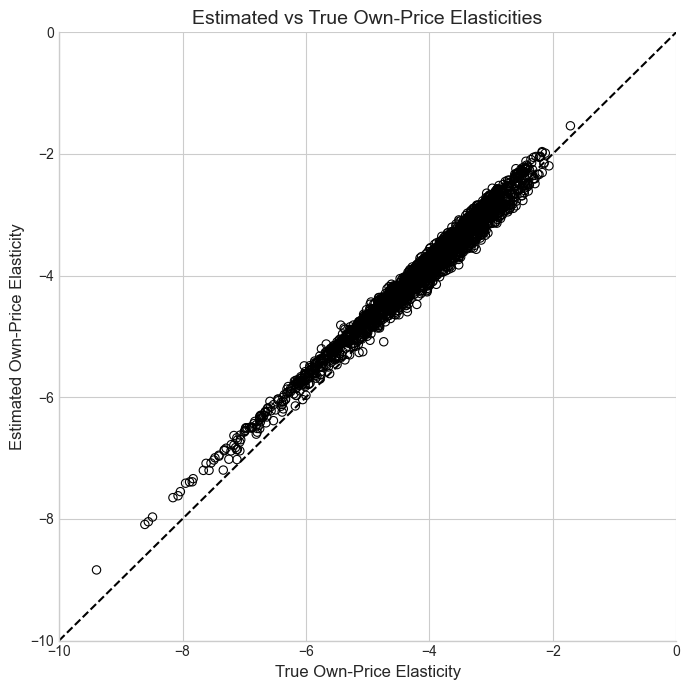

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------
# Estimated elasticities
# ---------------------------------
estimated_elasticities = results_joint.compute_elasticities()
estimated_own = results_joint.extract_diagonals(estimated_elasticities).flatten()

df = df.copy()
df["estimated_own_elasticity"] = estimated_own

# ---------------------------------
# True elasticities
# ---------------------------------
true_elasticities = simulation_results.compute_elasticities()
true_own = simulation_results.extract_diagonals(true_elasticities).flatten()

df["true_own_elasticity"] = true_own

# ---------------------------------
# Plot
# ---------------------------------
plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(figsize=(7,7))

ax.scatter(
    df["true_own_elasticity"],
    df["estimated_own_elasticity"],
    facecolors="none",      # no fill
    edgecolors="black",     # black circles
    linewidth=0.8
)

# 45-degree line
ax.plot([-10,0], [-10,0], linestyle="--", color="black", linewidth=1.5)

# Axis limits
ax.set_xlim(-10,0)
ax.set_ylim(-10,0)

# Labels
ax.set_xlabel("True Own-Price Elasticity", fontsize=12)
ax.set_ylabel("Estimated Own-Price Elasticity", fontsize=12)
ax.set_title("Estimated vs True Own-Price Elasticities", fontsize=14)

# Remove extra borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

Computing markups ...
Finished after 00:00:01.



C:\Users\narde\AppData\Local\Temp\ipykernel_72452\3795614856.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  viridis = cm.get_cmap("viridis")


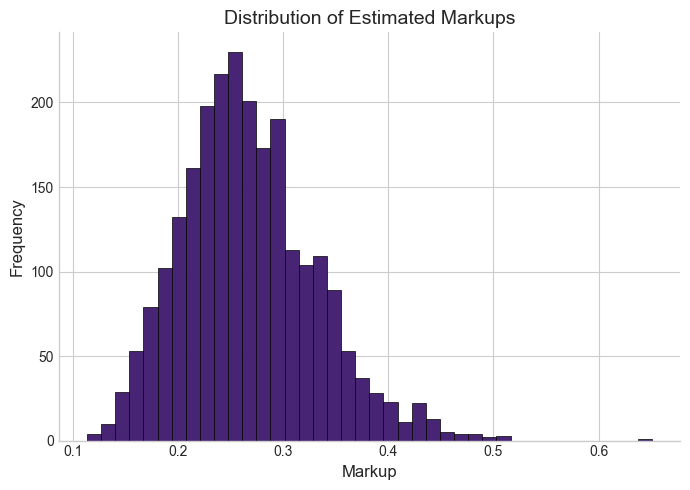

In [32]:
from matplotlib import cm

# Compute markups
markups = results_joint.compute_markups().flatten()

# Viridis purple shade
viridis = cm.get_cmap("viridis")
purple = viridis(0.1)   # lower values are purple in viridis

# Plot style
plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(figsize=(7,5))

ax.hist(
    markups,
    bins=40,
    color=purple,
    edgecolor="black",
    linewidth=0.5
)

ax.set_xlabel("Markup", fontsize=12)
ax.set_ylabel("Frequency", fontsize=12)
ax.set_title("Distribution of Estimated Markups", fontsize=14)

# Clean axes
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

Computing elasticities with respect to prices ...
Finished after 00:00:00.



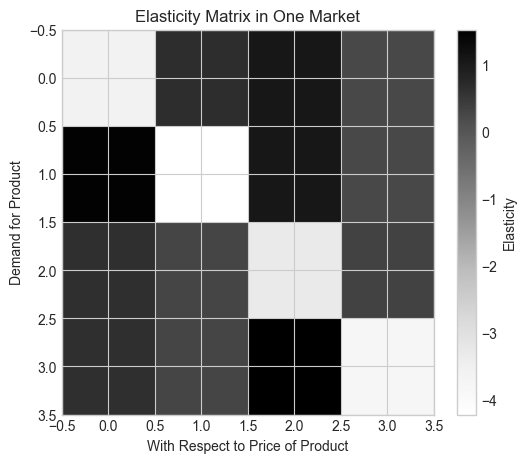

In [39]:
elasticity_market = results_joint.compute_elasticities(market_id=df["market_ids"].iloc[0])

plt.figure(figsize=(6,5))
plt.imshow(elasticity_market, aspect="auto")
plt.colorbar(label="Elasticity")
plt.xlabel("With Respect to Price of Product")
plt.ylabel("Demand for Product")
plt.title("Elasticity Matrix in One Market")
plt.show()